# Model Evaluation Tools (PCMLAI-aligned)

**Purpose:** Ready-to-run notebook that evaluates tabular IDS models with scikit-learn tools:
- Cross-validation (StratifiedKFold / TimeSeriesSplit)
- OOF PR curve (no leakage)
- Learning & validation curves
- GridSearchCV & RandomizedSearchCV (LightGBM by default; LR fallback)
- Threshold selection (F1@τ) + TPR/TNR report
- Outputs saved under `staging/eval_cv/`

**Course alignment:**
- **Module 3:** Probabilistic modelling, PR curves under imbalance.
- **Module 10:** Model selection & black-box optimisation; CV best practices.
- **Bandits/RL:** Explore–exploit intuition (for BO; here we focus on CV & search baselines).

## 1) Config & Paths

In [1]:
import os, json, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime

RANDOM_STATE = 42
DATA_PATH = "archive/Payload_data_UNSW.csv"  # change if needed
OUT_DIR = Path("staging/eval_cv"); OUT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(suppress=True, linewidth=160)
pd.set_option("display.width", 160)

## 2) Data loader (robust binary label mapping)
Maps **benign → 0**, **anything else → 1**. Keeps features `X` separate from target `y`.

In [2]:
def load_binary_dataset(csv_path: str):
    df = pd.read_csv(csv_path)
    candidates = ["label","label_str","attack_cat","class","target","y"]
    present = [c for c in candidates if c in df.columns]
    assert present, f"No expected label column found. Columns: {list(df.columns)[:30]}"
    src = present[0]
    s = df[src]
    benign_tokens = {"benign","normal","background","bg","clean"}
    if pd.api.types.is_numeric_dtype(s) and set(pd.unique(s.dropna())) <= {0,1}:
        y = s.astype(int).to_numpy()
    else:
        y = (~s.astype("string").str.strip().str.lower().isin(benign_tokens)).astype(int).to_numpy()
    df["label"] = y
    X = df.drop(columns=["label"])  # modelling features
    return X, y, df

X, y, df_full = load_binary_dataset(DATA_PATH)
print("Data shape:", df_full.shape, "| Features:", X.shape[1])
print("Pos rate:", float(np.mean(y)))

Data shape: (79881, 1505) | Features: 1504
Pos rate: 0.7371089495624742


## 3) Base estimator (LightGBM if available; LR fallback)
LightGBM handles tabular well; if not installed, use LogisticRegression so this notebook always runs.

In [3]:
try:
    from lightgbm import LGBMClassifier
    BASE_ESTIMATOR = LGBMClassifier(
        objective="binary", n_estimators=300, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight="balanced", verbosity=-1
    )
    IS_LGBM = True
except Exception:
    from sklearn.linear_model import LogisticRegression
    BASE_ESTIMATOR = LogisticRegression(max_iter=200, class_weight="balanced", random_state=RANDOM_STATE)
    IS_LGBM = False
print("Using:", BASE_ESTIMATOR.__class__.__name__)

# simple dtype normalisation for safety (objects -> string factor codes)
def normalise_dtypes(df: pd.DataFrame):
    Xn = df.copy()
    for c in Xn.columns:
        if str(Xn[c].dtype) == "category":
            Xn[c] = Xn[c].cat.codes
        elif Xn[c].dtype == bool:
            Xn[c] = Xn[c].astype(np.int8)
        elif Xn[c].dtype == object:
            cats = pd.Index(Xn[c].astype("string").unique())
            Xn[c] = Xn[c].astype("string").map({v:i for i,v in enumerate(cats)}).astype("int32")
    Xn = Xn.fillna(0)
    return Xn

Xn = normalise_dtypes(X)
print("After normalisation → numeric matrix shape:", Xn.shape)

Using: LGBMClassifier
After normalisation → numeric matrix shape: (79881, 1504)


## 4) Cross-validated metrics (AUPRC & F1)
Uses `cross_validate` with **StratifiedKFold** to get mean±std performance estimates.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"ap": "average_precision", "f1": "f1"}

cv_out = cross_validate(BASE_ESTIMATOR, Xn, y, scoring=scoring, cv=cv, n_jobs=-1, return_estimator=False)
print("AUPRC mean±std:", f"{cv_out['test_ap'].mean():.4f} ± {cv_out['test_ap'].std():.4f}")
print("F1    mean±std:", f"{cv_out['test_f1'].mean():.4f} ± {cv_out['test_f1'].std():.4f}")

pd.DataFrame(cv_out)[["test_ap","test_f1","fit_time"]].to_csv(OUT_DIR/"cv_summary.csv", index=False)
print("Saved:", OUT_DIR/"cv_summary.csv")

AUPRC mean±std: 0.9998 ± 0.0001
F1    mean±std: 0.9996 ± 0.0001
Saved: staging/eval_cv/cv_summary.csv


## 5) OOF PR curve (no leakage)
Use `cross_val_predict(..., method='predict_proba')` to build **out-of-fold** probabilities for a single PR curve reflecting CV generalisation.

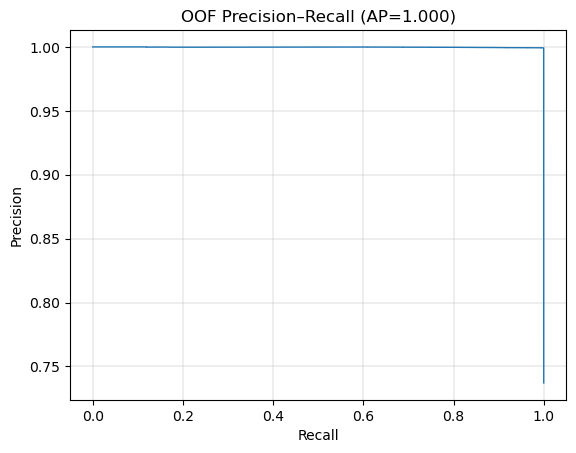

Saved OOF proba: staging/eval_cv/oof_proba.npy


In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

oof_proba = cross_val_predict(BASE_ESTIMATOR, Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:,1]
ap_oof = average_precision_score(y, oof_proba)
P, R, _ = precision_recall_curve(y, oof_proba)

plt.figure()
plt.plot(R, P, linewidth=1)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"OOF Precision–Recall (AP={ap_oof:.3f})")
plt.grid(True, linewidth=0.3)
plt.show()

np.save(OUT_DIR/"oof_proba.npy", oof_proba)
print("Saved OOF proba:", OUT_DIR/"oof_proba.npy")

## 6) Learning curves (sample size → AUPRC)
Diagnose **high bias vs high variance**: does more data help? Uses `learning_curve` with **Average Precision** scorer.

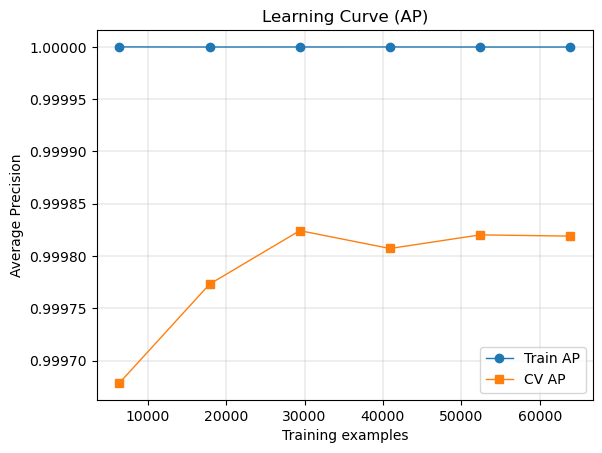

Saved: staging/eval_cv/learning_curve_ap.csv


In [6]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    BASE_ESTIMATOR, Xn, y, cv=cv, scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker='o', linewidth=1, label="Train AP")
plt.plot(train_sizes, val_mean, marker='s', linewidth=1, label="CV AP")
plt.xlabel("Training examples"); plt.ylabel("Average Precision")
plt.title("Learning Curve (AP)")
plt.grid(True, linewidth=0.3); plt.legend()
plt.show()

pd.DataFrame({"train_size":train_sizes, "train_ap":train_mean, "cv_ap":val_mean}).to_csv(OUT_DIR/"learning_curve_ap.csv", index=False)
print("Saved:", OUT_DIR/"learning_curve_ap.csv")

## 7) Validation curve (hyperparam → AUPRC)
Probe a **single** hyperparameter’s effect on AP (e.g., `num_leaves` for LightGBM, or `C` for LogisticRegression).

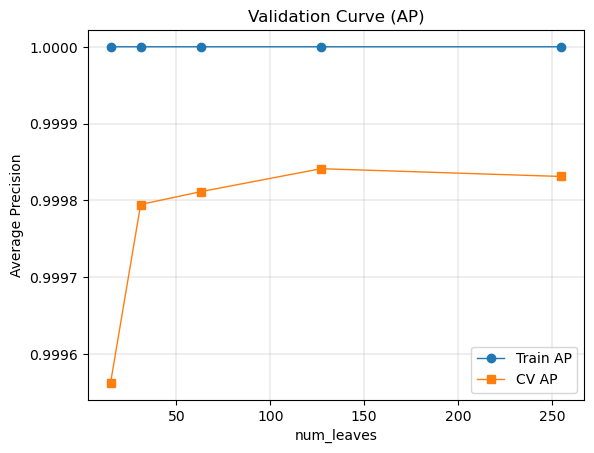

Saved: staging/eval_cv/validation_curve_ap.csv


In [7]:
from sklearn.model_selection import validation_curve

if IS_LGBM:
    param_name = "num_leaves"; param_range = [15, 31, 63, 127, 255]
else:
    param_name = "C"; param_range = np.logspace(-2, 2, 6)

train_scores, val_scores = validation_curve(
    BASE_ESTIMATOR, Xn, y, param_name=param_name, param_range=param_range,
    scoring="average_precision", cv=cv, n_jobs=-1
)
plt.figure()
plt.plot(param_range, train_scores.mean(axis=1), marker='o', linewidth=1, label="Train AP")
plt.plot(param_range, val_scores.mean(axis=1), marker='s', linewidth=1, label="CV AP")
plt.xlabel(param_name); plt.ylabel("Average Precision")
plt.title("Validation Curve (AP)"); plt.grid(True, linewidth=0.3); plt.legend(); plt.show()

pd.DataFrame({
    param_name: param_range,
    "train_ap": train_scores.mean(axis=1),
    "cv_ap": val_scores.mean(axis=1)
}).to_csv(OUT_DIR/"validation_curve_ap.csv", index=False)
print("Saved:", OUT_DIR/"validation_curve_ap.csv")

## 8) GridSearchCV (AP scorer)
Small grid for demonstration. Saves full `cv_results_` to CSV.

In [8]:
from sklearn.model_selection import GridSearchCV

if IS_LGBM:
    grid = {"num_leaves": [31, 63, 127], "learning_rate": [0.05, 0.1]}
else:
    grid = {"C": np.logspace(-2, 1, 4)}

gs = GridSearchCV(BASE_ESTIMATOR, grid, scoring="average_precision", cv=cv, n_jobs=-1, verbose=1, refit=True)
gs.fit(Xn, y)
print("Best params:", gs.best_params_, "| best CV AP:", f"{gs.best_score_:.4f}")
gs_df = pd.DataFrame(gs.cv_results_); gs_df.to_csv(OUT_DIR/"gridsearch_results.csv", index=False)
print("Saved:", OUT_DIR/"gridsearch_results.csv")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'learning_rate': 0.1, 'num_leaves': 127} | best CV AP: 0.9998
Saved: staging/eval_cv/gridsearch_results.csv


## 9) RandomizedSearchCV (AP scorer)
Covers broader space quickly. Saves `cv_results_` to CSV.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

if IS_LGBM:
    dist = {
        "num_leaves": randint(16, 256),
        "max_depth": randint(2, 16),
        "min_child_samples": randint(10, 200),
        "subsample": loguniform(0.6, 1.0),
        "colsample_bytree": loguniform(0.6, 1.0),
        "learning_rate": loguniform(1e-3, 2e-1),
        "reg_lambda": loguniform(1e-3, 10.0)
    }
else:
    dist = {"C": loguniform(1e-2, 1e2)}

rs = RandomizedSearchCV(BASE_ESTIMATOR, dist, n_iter=30, scoring="average_precision",
                        cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1, refit=True)
rs.fit(Xn, y)
print("Best params:", rs.best_params_, "| best CV AP:", f"{rs.best_score_:.4f}")
rs_df = pd.DataFrame(rs.cv_results_); rs_df.to_csv(OUT_DIR/"randomsearch_results.csv", index=False)
print("Saved:", OUT_DIR/"randomsearch_results.csv")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


python(74701) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(74716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(74719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## 10) Time-aware CV (optional)
For chronological data, avoid look-ahead with `TimeSeriesSplit` (expanding window). We report AP only (can add others).

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

tscv = TimeSeriesSplit(n_splits=5)
t_out = cross_validate(BASE_ESTIMATOR, Xn, y, scoring={"ap":"average_precision"}, cv=tscv, n_jobs=-1)
print("TimeSeriesSplit AP mean±std:", f"{t_out['test_ap'].mean():.4f} ± {t_out['test_ap'].std():.4f}")
pd.DataFrame(t_out)[["test_ap","fit_time"]].to_csv(OUT_DIR/"tscv_ap.csv", index=False)
print("Saved:", OUT_DIR/"tscv_ap.csv")

## 11) Threshold selection & SOC report (F1@τ, TPR/TNR)
Pick τ that maximises F1 on **OOF probabilities**. Report TPR/TNR at τ (operational view).

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

def sweep_f1(y_true, p_hat, grid=np.linspace(0.05,0.95,19)):
    f1s=[]
    for t in grid:
        f1s.append(f1_score(y_true, (p_hat>=t).astype(int), zero_division=0))
    j=int(np.argmax(f1s)); return float(f1s[j]), float(grid[j])

best_f1, tau = sweep_f1(y, oof_proba)
y_hat = (oof_proba >= tau).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()
tpr = tp/(tp+fn) if (tp+fn) else 0.0
tnr = tn/(tn+fp) if (tn+fp) else 0.0
print(f"OOF F1@τ={best_f1:.4f} | τ={tau:.2f} | TPR={tpr:.3f} | TNR={tnr:.3f}")

manifest = {
    "timestamp": datetime.utcnow().isoformat()+"Z",
    "stage": "model_eval_tools",
    "dataset": DATA_PATH,
    "seed": RANDOM_STATE,
    "metrics": {"AUPRC_OOF": float(ap_oof), "F1_OOF": float(best_f1), "tau": float(tau), "TPR": float(tpr), "TNR": float(tnr)}
}
(OUT_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved manifest:", OUT_DIR/"manifest.json")

## 12) Ensembles Overview (PCMLAI-aligned)
- **Why (Module 10):** Ensembles reduce variance (bagging), reduce bias (boosting), or combine complementary models (stacking/voting).
- **IDS context:** Better AUPRC under class imbalance; more stable thresholds (τ) for SOC.
- **What we’ll add:** Bagging, Random Forest, Gradient Boosting, Soft Voting, and Stacking — all evaluated by **OOF PR-AUC** with the same CV.


In [ ]:
# 13) Helpers for ensembles
import numpy as np, pandas as pd, json
from pathlib import Path
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_predict

ENSEMBLE_DIR = OUT_DIR / "ensembles"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

def sweep_f1_local(y_true, p, grid=np.linspace(0.05, 0.95, 19)):
    f1s = []
    for t in grid:
        f1s.append(f1_score(y_true, (p >= t).astype(int), zero_division=0))
    j = int(np.argmax(f1s))
    return float(f1s[j]), float(grid[j])

def eval_and_stage_oof(name: str, oof_proba: np.ndarray):
    """Compute OOF metrics, save preds + metrics json."""
    ap = average_precision_score(y, oof_proba)
    f1o, tau = sweep_f1_local(y, oof_proba)
    yb = (oof_proba >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yb).ravel()
    TPR = tp/(tp+fn) if (tp+fn) else 0.0
    TNR = tn/(tn+fp) if (tn+fp) else 0.0

    np.save(ENSEMBLE_DIR / f"{name}_oof.npy", oof_proba)
    meta = {
        "name": name,
        "AUPRC_OOF": float(ap),
        "F1_OOF": float(f1o),
        "tau": float(tau),
        "TPR": float(TPR),
        "TNR": float(TNR),
    }
    (ENSEMBLE_DIR / f"{name}_metrics.json").write_text(json.dumps(meta, indent=2))
    print(f"[{name}] OOF AP={ap:.4f} | F1@τ={f1o:.4f} | τ={tau:.2f} | TPR={TPR:.3f} | TNR={TNR:.3f}")
    return meta


In [ ]:
# 14) Bagging & Random Forest
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Base learner for Bagging: shallow tree stump or logistic regression can be used;
# use a simple depth-limited tree for speed & variance reduction.
from sklearn.tree import DecisionTreeClassifier
base_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight="balanced")

bag = BaggingClassifier(
    base_estimator=base_tree,
    n_estimators=100,
    max_samples=0.9,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# OOF probabilities (no leakage)
oof_bag = cross_val_predict(bag, Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
oof_rf  = cross_val_predict(rf,  Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:,  1]

m_bag = eval_and_stage_oof("bagging", oof_bag)
m_rf  = eval_and_stage_oof("random_forest", oof_rf)


In [ ]:
# 15) Gradient Boosting + Soft Voting
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

# We'll combine three diverse learners for Voting:
#   LogisticRegression (linear), RandomForest (nonlinear bagging), GradientBoosting (nonlinear boosting)
lr = LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)

voting = VotingClassifier(
    estimators=[("lr", lr), ("rf", RandomForestClassifier(n_estimators=250, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
                ("gb", GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, random_state=RANDOM_STATE))],
    voting="soft", n_jobs=-1
)

oof_gb  = cross_val_predict(gb,     Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
oof_vot = cross_val_predict(voting, Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

m_gb  = eval_and_stage_oof("gradient_boosting", oof_gb)
m_vot = eval_and_stage_oof("voting_soft",       oof_vot)


In [ ]:
# 16) Stacking (meta-learner on CV level-1 features)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base layer similar to voting, meta is logistic regression
stack = StackingClassifier(
    estimators=[("lr", LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)),
                ("rf", RandomForestClassifier(n_estimators=250, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
                ("gb", GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, random_state=RANDOM_STATE))],
    final_estimator=LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

oof_stack = cross_val_predict(stack, Xn, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
m_stack   = eval_and_stage_oof("stacking", oof_stack)


## 17) Consolidate ensemble metrics & update eval manifest
- We aggregate all ensemble OOF metrics and **update** `staging/eval_cv/manifest.json`.
- Your existing **Champion + Model_Evaluation_Tools Auto-Wire** cell in *Label_Trainer* will pick this up automatically and write to `model_card.md` / `README.md`.


In [ ]:
# 17) Consolidate ensemble metrics and update main eval manifest
import json
from datetime import datetime

# Read existing manifest (if any)
eval_manifest_path = OUT_DIR / "manifest.json"
existing = {}
if eval_manifest_path.exists():
    try:
        existing = json.loads(eval_manifest_path.read_text())
    except Exception:
        existing = {}

# Accumulate ensemble metrics
agg = []
for js in ENSEMBLE_DIR.glob("*_metrics.json"):
    try:
        agg.append(json.loads(js.read_text()))
    except Exception:
        pass

# Write a side summary CSV too
if agg:
    pd.DataFrame(agg).to_csv(OUT_DIR / "ensemble_oof_summary.csv", index=False)
    print("Saved:", OUT_DIR / "ensemble_oof_summary.csv")

# Merge into manifest under key "ensembles"
existing.setdefault("timestamp", datetime.utcnow().isoformat() + "Z")
existing.setdefault("stage", "model_eval_tools")
existing.setdefault("dataset", DATA_PATH)
existing.setdefault("seed", RANDOM_STATE)
existing.setdefault("metrics", existing.get("metrics", {}))
existing["ensembles"] = agg

eval_manifest_path.write_text(json.dumps(existing, indent=2))
print("Updated manifest:", eval_manifest_path)
